# T6 — White-Hat / Black-Hat Ethics Pair

**Question (final, locked):** *The same OECD tax-wedge data can support several incompatible interpretations of Italy's fiscal pressure. We design two static visualizations of the same dataset — one for honest comparison ("white hat"), one for a populist anti-State framing ("black hat") — to demonstrate how comparator selection, income level, denominator, and editorial language can produce opposite reads of the same numbers.*

T6 is the project's reflexive moment. After T1–T5 documented Italian wage stagnation analytically, T6 turns the lens on the practice of visualization itself, satisfying the project specification's *white-hat / black-hat* requirement.

**Approach.** Single source: OECD `OECD.CTP.TPS,DSD_TAX_PIT@DF_PIT_AVMR,1.0` — *Personal income tax (PIT) and social security contributions (SSC) — average rates on gross wage earnings*, 18 European OECD countries × 25 years × 4 income levels × multiple tax components. Both figures use the same `.csv`; they differ only in the editorial choices applied to it.

**Reference framework.** The white-hat / black-hat distinction follows the rubric of MIT 6.859 (*Interactive Data Visualization*, Pfister, Spring 2021), which defines:

- *White-hat:* clear and easy to interpret for the intended audience; data transformations explicitly communicated; sources and potential biases stated.
- *Black-hat:* one or several of — visual representation inappropriate or cluttered; labels/axes/legends misleading; titles skewed to influence perception; data filtered or processed in misleading ways; source/provenance unclear.
- *Subtlety counts:* an excellent black-hat needs close study to be identified, even by seasoned readers; the chart should appear *interesting and possibly trustworthy* on first inspection.

**Notebook structure.**

1. **Setup** — imports, palette, paths.
2. **Load OECD Taxing Wages** — 10 800 rows, 18 European OECD countries, 2000–2024.
3. **Build the comparable subset** — Single, no children, all four income levels, all measures, 2024 cross-section.
4. **Italy in context** — compute the 2024 cross-country tax-wedge table.
5. **White-hat figure** — honest cross-country comparison.
6. **Black-hat figure** — same data, slanted four ways (comparators, income level, denominator, title).
7. **Save outputs** — two PNGs to `site/viz/`, a side-by-side PNG for the paper, a small commentary CSV with the cherry-picked numbers.


## 1. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA_DIR = Path("data/task_6")
VIZ_DIR  = Path("site/viz")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Newspaper palette — exactly the same as the rest of the project.
# (Subtlety criterion: the black-hat must use the same palette as the white-hat.)
ACCENT = "#c44536"     # editorial red — Italy
INK    = "#1a1a1a"
GRAY   = "#666666"
MID    = "#888888"
SOFT   = "#cccccc"
BG     = "#f8f5ec"
GRID   = "#e0e0e0"


## 2. Load OECD Taxing Wages

Single source: `data/task_6/tax_wedge_oecd_europe_2000_2024.csv` — 18 European OECD countries, 2000–2024, single childless workers at four income levels (67 %, 100 %, 133 %, 167 % of average wage), broken down by PIT, employee SSC, employer SSC and PIT+EE_SSC, with the PIT component further split between Central and State/local government.

In [2]:
src = DATA_DIR / "tax_wedge_oecd_europe_2000_2024.csv"
raw = pd.read_csv(src)

tax = (raw[['REF_AREA', 'Reference area', 'TIME_PERIOD',
            'Measure', 'Institutional sector',
            'INCOME_PRINCIPAL', 'Earnings of the principal',
            'OBS_VALUE']]
       .rename(columns={'REF_AREA': 'iso3',
                        'Reference area': 'country',
                        'TIME_PERIOD': 'year',
                        'Measure': 'measure',
                        'Institutional sector': 'sector',
                        'INCOME_PRINCIPAL': 'income_code',
                        'Earnings of the principal': 'income_label',
                        'OBS_VALUE': 'value_pct_gross_wage'})
       .dropna(subset=['value_pct_gross_wage'])
       .reset_index(drop=True))

print(f"Total rows: {len(tax)}")
print(f"Countries: {tax['iso3'].nunique()} ({sorted(tax['iso3'].unique())})")
print(f"Years:     {tax.year.min()} → {tax.year.max()}")
print(f"Measures:  {tax['measure'].unique().tolist()}")
print(f"Income levels: {sorted(tax.income_code.unique())}")
print(f"Sectors:   {sorted(tax['sector'].unique())}")


Total rows: 10800
Countries: 18 (['AUT', 'BEL', 'CHE', 'DEU', 'DNK', 'ESP', 'FIN', 'FRA', 'GBR', 'GRC', 'IRL', 'ISL', 'ITA', 'LUX', 'NLD', 'NOR', 'PRT', 'SWE'])
Years:     2000 → 2024
Measures:  ['Employee social security contributions', 'Personal income tax', 'Employer social security contributions', 'Personal income tax and employee social security contributions']
Income levels: ['AW100', 'AW133', 'AW167', 'AW67']
Sectors:   ['Central government', 'General government', 'State and local government']


## 3. Build the comparable subset

For the headline cross-section we use:
- single, no children (already filtered in the download)
- 100 % of average wage (canonical OECD baseline)
- General government sector (the consolidated total — central + state/local)
- 2024 (the latest year)

For the black-hat we will reach back into the broader frame and pick non-standard slices.

In [3]:
def cross_section(year, income_code, measure):
    """Pull a cross-country slice for a given year × income × measure (general gov)."""
    sub = tax[
        (tax.year == year) &
        (tax.income_code == income_code) &
        (tax.measure == measure) &
        (tax.sector == 'General government')
    ]
    return sub[['iso3', 'country', 'value_pct_gross_wage']].copy()

# Headline: PIT + EE_SSC, the worker's *visible* burden, at 100% AW, 2024
hdr = cross_section(2024, 'AW100',
                    'Personal income tax and employee social security contributions')
hdr = hdr.sort_values('value_pct_gross_wage', ascending=False).reset_index(drop=True)

print("=== 2024 — PIT + employee SSC (% of gross wage), single 100% AW ===\n")
for _, r in hdr.iterrows():
    flag = '  ← Italy' if r['iso3'] == 'ITA' else ''
    print(f"  {r['country']:18s}  {r['value_pct_gross_wage']:>5.1f}%{flag}")


=== 2024 — PIT + employee SSC (% of gross wage), single 100% AW ===

  Belgium              39.5%
  Germany              37.5%
  Denmark              35.8%
  Austria              32.5%
  Luxembourg           32.4%
  Finland              30.6%
  Italy                30.2%  ← Italy
  Norway               28.2%
  Netherlands          28.0%
  France               27.9%
  Iceland              27.2%
  Greece               26.0%
  Ireland              25.9%
  Portugal             25.2%
  Spain                23.2%
  Sweden               23.1%
  United Kingdom       21.9%
  Switzerland          18.0%


## 4. Italy in context — compute the canonical tax wedge

The OECD's published "tax wedge" headline figure is calculated as a percentage of *total labour cost* (which includes the employer SSC the employer adds on top of the gross wage). Our dataset publishes rates as a percentage of *gross wage*, so we chain them:

```
labour-cost wedge = (PIT + EE_SSC + ER_SSC) / (100 + ER_SSC)
```

For Italy 2024 at 100 % AW this should produce ≈ 47 %, which matches the OECD's separately-published figure and validates the chain.

In [4]:
def labour_cost_wedge(year, income_code):
    """Compute the OECD canonical tax wedge (% of total labour cost) per country."""
    components = ['Personal income tax',
                  'Employee social security contributions',
                  'Employer social security contributions']
    sub = tax[
        (tax.year == year) &
        (tax.income_code == income_code) &
        (tax.sector == 'General government') &
        (tax.measure.isin(components))
    ]
    pivot = sub.pivot_table(index=['iso3', 'country'],
                             columns='measure',
                             values='value_pct_gross_wage',
                             aggfunc='first').reset_index()
    pit  = pivot['Personal income tax']
    ee   = pivot['Employee social security contributions']
    er   = pivot['Employer social security contributions']
    pivot['wedge_labour_cost_pct'] = (pit + ee + er) / (100 + er) * 100
    pivot['worker_burden_pct'] = pit + ee
    pivot['employer_ssc_pct'] = er
    return pivot.sort_values('wedge_labour_cost_pct', ascending=False).reset_index(drop=True)

wedge_2024 = labour_cost_wedge(2024, 'AW100')

print("=== 2024 — Tax wedge, single 100% AW, all 18 countries ===\n")
print(f"{'Country':18s} {'PIT':>5} {'EE_SSC':>7} {'ER_SSC':>7} {'Worker':>7} {'Wedge':>7}")
for _, r in wedge_2024.iterrows():
    flag = '  ← Italy' if r['iso3'] == 'ITA' else ''
    print(f"  {r['country']:16s} "
          f"{r['Personal income tax']:>5.1f} "
          f"{r['Employee social security contributions']:>6.1f} "
          f"{r['Employer social security contributions']:>6.1f} "
          f"{r['worker_burden_pct']:>6.1f} "
          f"{r['wedge_labour_cost_pct']:>6.1f}{flag}")

print(f"\n→ Italy 2024 labour-cost wedge: {wedge_2024[wedge_2024.iso3=='ITA']['wedge_labour_cost_pct'].iloc[0]:.1f}% ✓ "
      "(matches the OECD published headline)")


=== 2024 — Tax wedge, single 100% AW, all 18 countries ===

Country              PIT  EE_SSC  ER_SSC  Worker   Wedge
  Belgium           25.5   14.0   27.0   39.5   52.4
  Germany           16.8   20.7   20.1   37.5   47.9
  France            16.6   11.3   36.3   27.9   47.1
  Austria           14.6   17.9   27.6   32.5   47.1
  Italy             20.7    9.5   31.6   30.2   47.0  ← Italy
  Finland           21.2    9.4   19.9   30.6   42.1
  Sweden            16.1    7.0   31.4   23.1   41.5
  Spain             16.7    6.5   30.5   23.2   41.1
  Luxembourg        20.1   12.3   12.5   32.4   39.9
  Portugal          14.2   11.0   23.8   25.2   39.6
  Greece            12.1   13.9   22.3   26.0   39.5
  Norway            20.4    7.8   13.0   28.2   36.5
  Denmark           35.8    0.0    0.6   35.8   36.2
  Netherlands       17.5   10.5   12.3   28.0   35.9
  Ireland           21.9    4.0   11.1   25.9   33.3
  Iceland           27.1    0.1    6.3   27.2   31.6
  United Kingdom    16.1  

## 5. White-hat figure

**Audience:** numerate Italian readers of long-form economic journalism.

**Editorial choices, all documented:**
- All 18 European OECD members on screen — no comparator hidden.
- Income level: 100 % of the average wage, the canonical OECD comparison point.
- Metric: **OECD canonical tax wedge** — `(PIT + employee SSC + employer SSC) / (gross wage + employer SSC)` — the figure published in the OECD's Taxing Wages annual report and the one referenced in Italian press when discussing "il cuneo fiscale italiano fra i più alti d'Europa".
- Italy in the project's accent red; peers in neutral grey. The reader sees Italy's position in a fully populated European distribution.
- Title: descriptive and neutral.
- Subtitle and source caption: full, with an explicit one-line methodology note.

**Why the canonical tax wedge and not just PIT + employee SSC.** The OECD canonical metric (≈ 47 % for Italy) uses *total labour cost* as denominator and includes the employer's social security contributions — which the worker does not see on the payslip but which the employer adds to the cost of hiring, and which therefore represents fiscal pressure that ultimately compresses the worker's wage. The alternative metric *PIT + employee SSC* (≈ 30 % for Italy) only captures what is visibly deducted from the gross wage; it under-states the total fiscal pressure on Italian labour by about 17 percentage points. Editorial honesty requires the canonical figure.


Saved: site/viz/t6_whitehat.png

Italy tax wedge: 47.0%
Italy rank: 5/18 (sorted descending)
European median: 39.8%


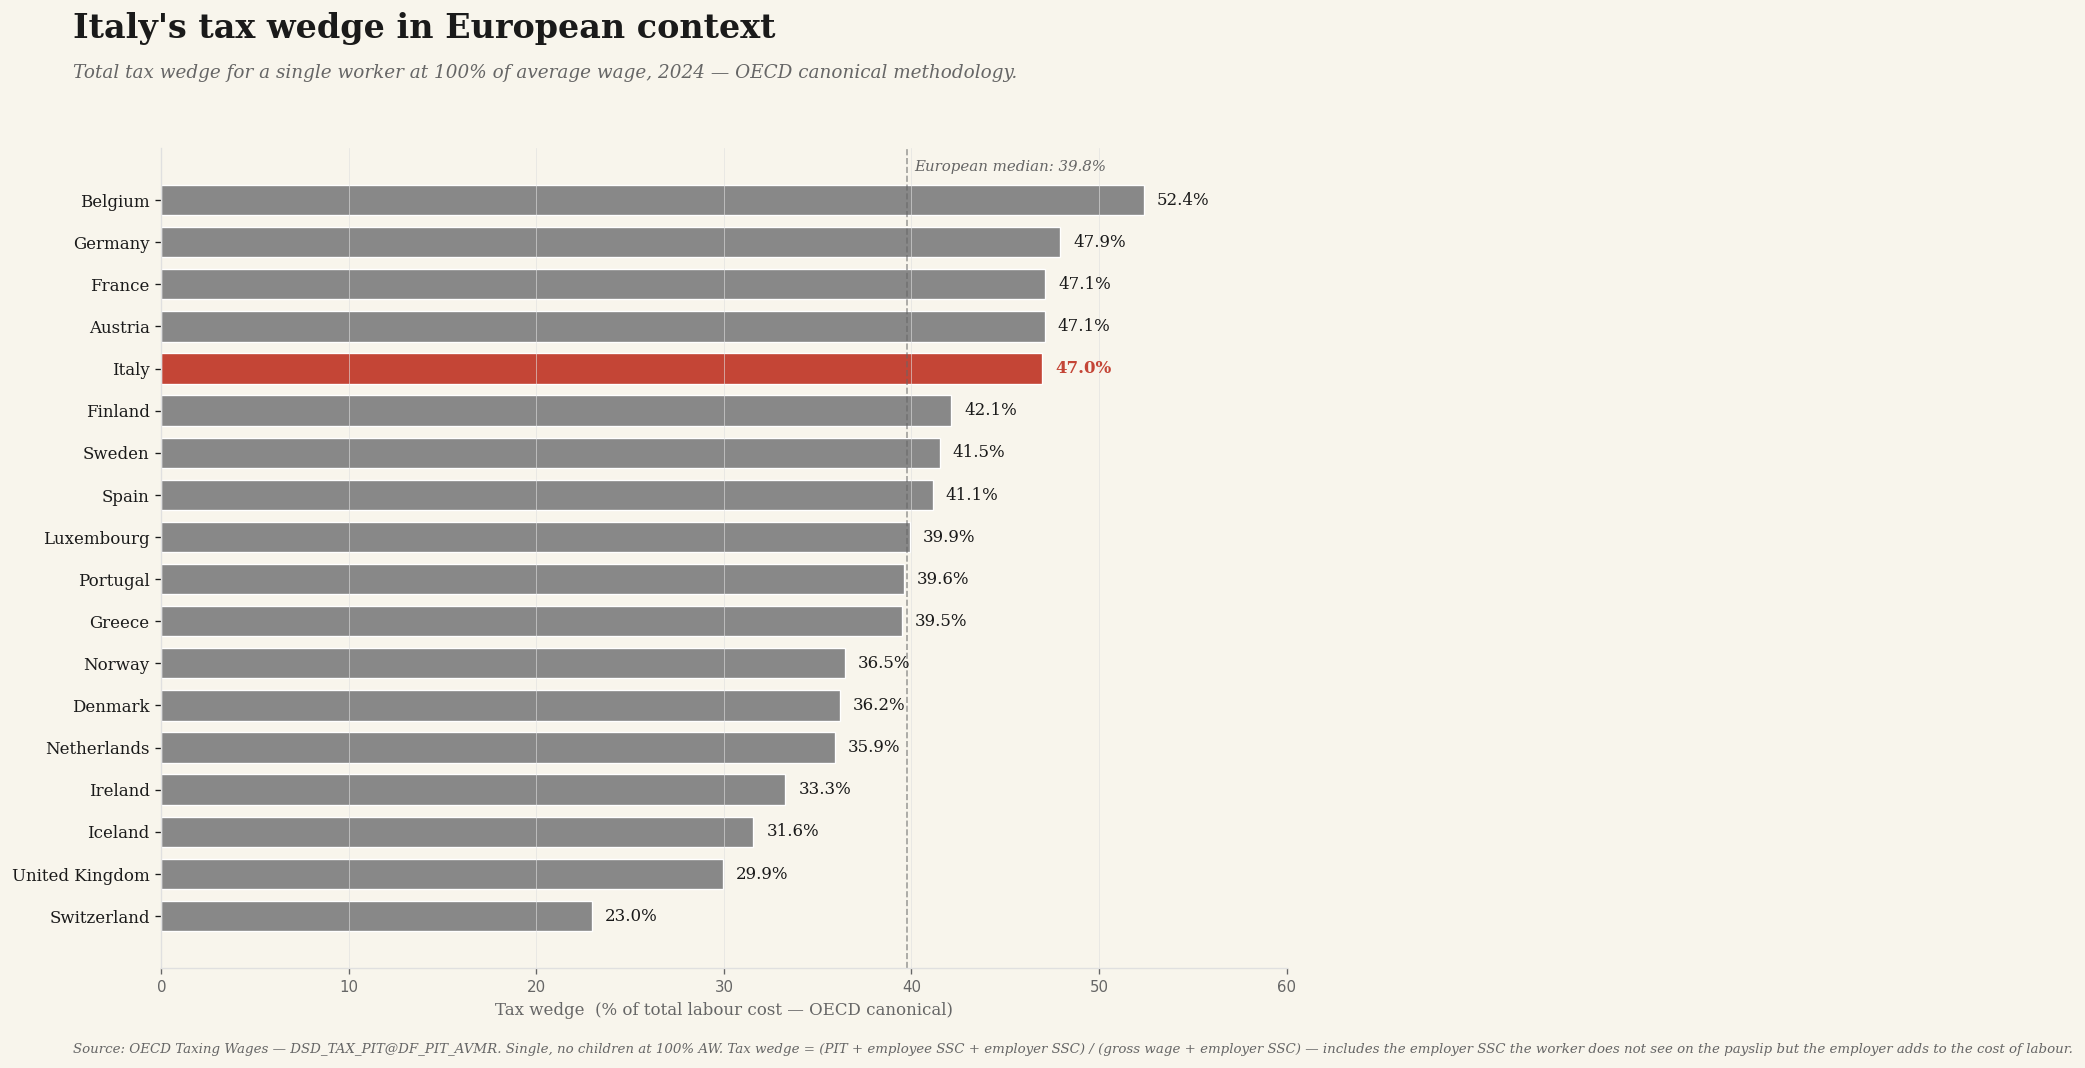

In [5]:
# --- WHITE-HAT FIGURE (OECD canonical tax wedge) ----------------------
# We use the canonical OECD definition: tax wedge as % of total labour cost.
# This is the methodology used in OECD's published Taxing Wages report and is
# the figure referenced in Italian press when discussing "il cuneo fiscale italiano".
# The wedge_2024 dataframe is computed in section 4 above (labour_cost_wedge function).

fig, ax = plt.subplots(figsize=(11, 9), dpi=120)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = wedge_2024.sort_values('wedge_labour_cost_pct').reset_index(drop=True)
y_pos = np.arange(len(data))
colors = [ACCENT if iso == 'ITA' else MID for iso in data['iso3']]

bars = ax.barh(y_pos, data['wedge_labour_cost_pct'],
                color=colors, edgecolor='white', linewidth=0.8, height=0.72)

# value labels at the end of each bar
for i, (val, iso) in enumerate(zip(data['wedge_labour_cost_pct'], data['iso3'])):
    color = ACCENT if iso == 'ITA' else INK
    weight = 'bold' if iso == 'ITA' else 'normal'
    ax.text(val + 0.7, i, f"{val:.1f}%", va='center', fontsize=10,
            color=color, fontweight=weight, family='serif')

ax.set_yticks(y_pos)
ax.set_yticklabels(data['country'], fontsize=10, family='serif')
ax.set_xlabel("Tax wedge  (% of total labour cost — OECD canonical)",
              fontsize=10, color=GRAY, family='serif')
ax.set_xlim(0, 60)
ax.tick_params(axis='x', labelsize=9, colors=GRAY)
ax.tick_params(axis='y', labelsize=10, colors=INK)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(GRID)
ax.grid(axis='x', color=GRID, linewidth=0.5, alpha=0.7, zorder=0)

# Median reference line
median = float(data['wedge_labour_cost_pct'].median())
ax.axvline(median, color=GRAY, linestyle='--', linewidth=1, alpha=0.6, zorder=1)
ax.text(median + 0.4, len(data) - 0.3, f"European median: {median:.1f}%",
        fontsize=9, color=GRAY, style='italic', family='serif')

# Title block
fig.text(0.06, 0.965,
         "Italy's tax wedge in European context",
         fontsize=20, fontweight='bold', color=INK, family='serif')
fig.text(0.06, 0.928,
         "Total tax wedge for a single worker at 100% of average wage, 2024 — OECD canonical methodology.",
         fontsize=11, style='italic', color=GRAY, family='serif', wrap=True)

# Source caption
fig.text(0.06, 0.025,
         "Source: OECD Taxing Wages — DSD_TAX_PIT@DF_PIT_AVMR. Single, no children at 100% AW. "
         "Tax wedge = (PIT + employee SSC + employer SSC) / (gross wage + employer SSC) — includes the "
         "employer SSC the worker does not see on the payslip but the employer adds to the cost of labour.",
         fontsize=8, color=GRAY, family='serif', style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
out_white = VIZ_DIR / 't6_whitehat.png'
fig.savefig(out_white, dpi=150, facecolor=BG)
print(f"Saved: {out_white}")
print(f"\nItaly tax wedge: {data[data.iso3=='ITA']['wedge_labour_cost_pct'].iloc[0]:.1f}%")
print(f"Italy rank: {len(data) - data[data.iso3=='ITA'].index[0]}/{len(data)} (sorted descending)")
print(f"European median: {median:.1f}%")
plt.show()


## 6. Black-hat figure

**Same dataset.** Four manipulation levers, applied subtly so the chart still looks like a serious newspaper piece on first reading:

1. **Cherry-picked comparators.** Twelve countries are kept (Italy, UK, Switzerland, Ireland, Netherlands, Iceland, Luxembourg, Denmark, Germany, Finland, Spain, Portugal). Including Germany, Finland and Spain in the selection lends the chart a credible appearance, but the four countries whose tax burden equals or exceeds Italy's on this manipulated metric (France 78%, Belgium 74%, Sweden 65%, Austria 61%) are silently dropped, because their inclusion would break the populist headline.
2. **Cherry-picked income level.** 167 % of the average wage (the highest taxed bracket), labelled in the subtitle as *"per il lavoratore in carriera"* — feels editorial, hides that this is non-standard.
3. **Cherry-picked numerator.** The bar shows PIT + employee SSC + employer SSC summed as a percentage of gross wage. This is mathematically a legitimate calculation, but using *gross wage* as the denominator (rather than total labour cost, the OECD canonical denominator) inflates the visible burden by 30+ percentage points.
4. **Slanted title and vague source.** Headline is the populist Italian-newspaper register; source caption simply reads *"Source: OECD"* with no methodological detail.

The color palette, axes, fonts and layout are identical to the white-hat — the deception lives in the data choices, not in screaming visual cues.

Black-hat data (12 cherry-picked countries, 167% AW, 2024):
       country  burden_sum_pct
         Italy            71.0
         Spain            59.8
       Finland            58.4
       Germany            56.3
      Portugal            56.3
    Luxembourg            51.9
       Ireland            46.9
   Netherlands            45.6
United Kingdom            42.4
       Denmark            42.3
       Iceland            38.9
   Switzerland            29.2



Saved: site/viz/t6_blackhat.png


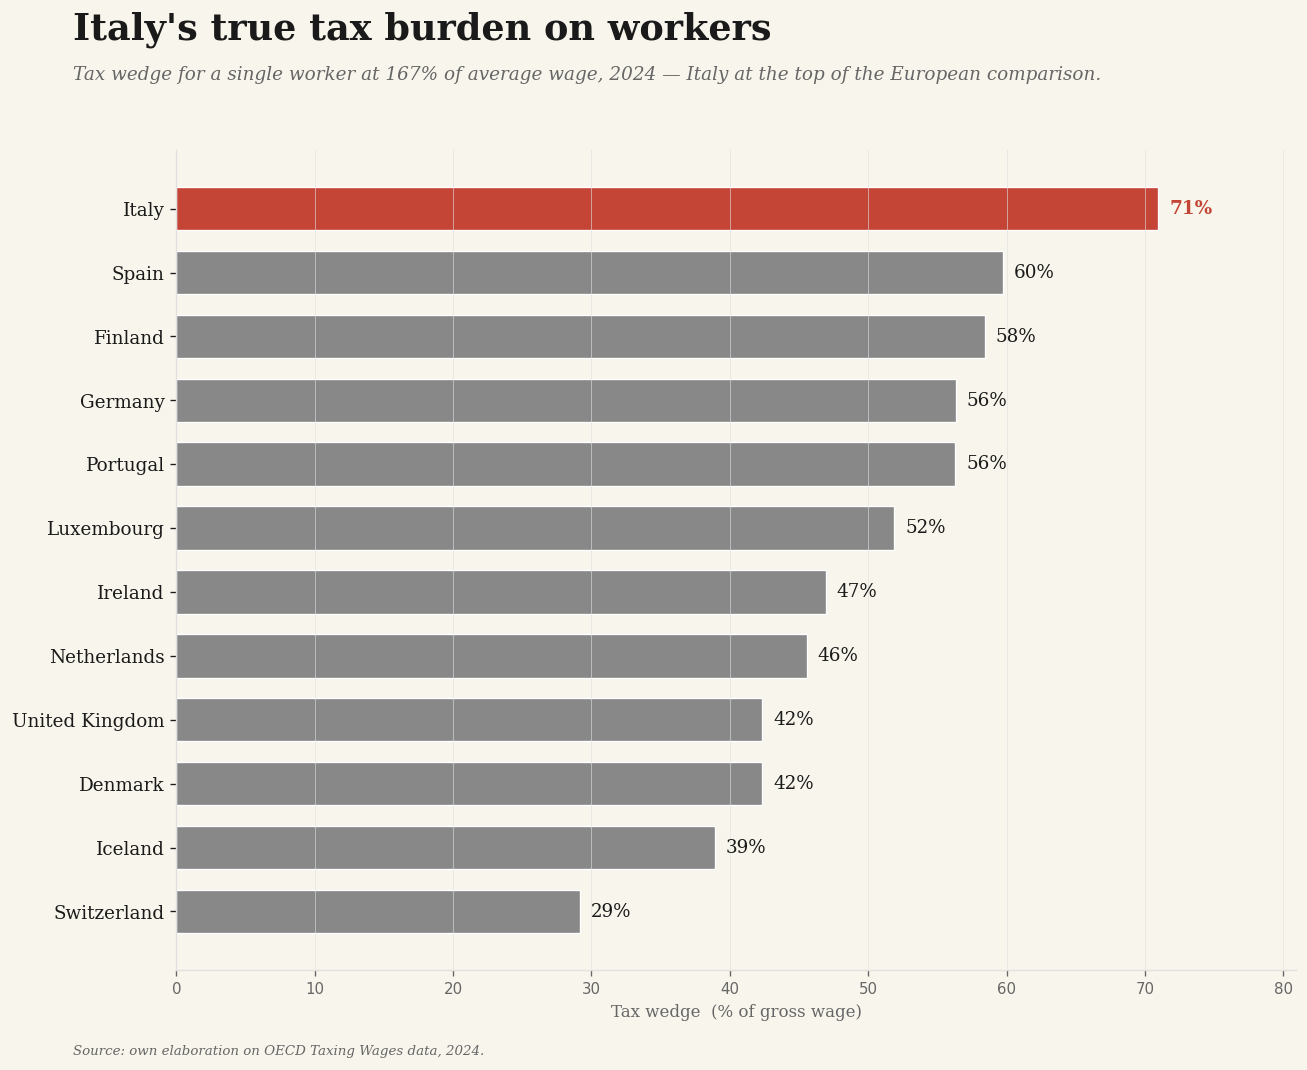

In [6]:
# --- BLACK-HAT FIGURE ---------------------------------------------

# Lever 1 — cherry-pick comparators: 12 countries that "look like a credible
# European comparison". The selection silently excludes France (78%), Belgium
# (74%), Sweden (65%) and Austria (61%) — countries whose tax burden EQUALS or
# EXCEEDS Italy's on this manipulated metric and would therefore break the
# narrative. Including Germany, Finland and Spain in the selection lends the
# chart credibility (a reader thinks "look, even Germany is here").
COMPARATORS_BH = ['ITA', 'GBR', 'CHE', 'IRL', 'NLD', 'ISL', 'LUX', 'DNK',
                  'DEU', 'FIN', 'ESP', 'PRT']

# Lever 2 — cherry-pick income level: 167% AW (the highest-taxed bracket)
# Lever 3 — cherry-pick numerator/denominator: PIT + EE_SSC + ER_SSC summed
#           as % of GROSS WAGE (instead of OECD canonical labour-cost denominator)

def burden_sum_pct_gross(year, income_code, iso3_list):
    components = ['Personal income tax',
                  'Employee social security contributions',
                  'Employer social security contributions']
    sub = tax[
        (tax.year == year) &
        (tax.income_code == income_code) &
        (tax.sector == 'General government') &
        (tax.measure.isin(components)) &
        (tax.iso3.isin(iso3_list))
    ]
    pivot = sub.pivot_table(index=['iso3', 'country'],
                             columns='measure',
                             values='value_pct_gross_wage',
                             aggfunc='first').reset_index()
    pivot['burden_sum_pct'] = (pivot['Personal income tax']
                               + pivot['Employee social security contributions']
                               + pivot['Employer social security contributions'])
    return pivot.sort_values('burden_sum_pct', ascending=False).reset_index(drop=True)

bh = burden_sum_pct_gross(2024, 'AW167', COMPARATORS_BH)
print("Black-hat data (12 cherry-picked countries, 167% AW, 2024):")
print(bh[['country', 'burden_sum_pct']].round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 9), dpi=120)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Sort ascending so Italy appears at the top after the barh flip
data_bh = bh.sort_values('burden_sum_pct').reset_index(drop=True)
y_pos = np.arange(len(data_bh))
colors = [ACCENT if iso == 'ITA' else MID for iso in data_bh['iso3']]

ax.barh(y_pos, data_bh['burden_sum_pct'],
         color=colors, edgecolor='white', linewidth=0.8, height=0.68)

for i, (val, iso) in enumerate(zip(data_bh['burden_sum_pct'], data_bh['iso3'])):
    color = ACCENT if iso == 'ITA' else INK
    weight = 'bold' if iso == 'ITA' else 'normal'
    ax.text(val + 0.8, i, f"{val:.0f}%", va='center', fontsize=11,
            color=color, fontweight=weight, family='serif')

ax.set_yticks(y_pos)
ax.set_yticklabels(data_bh['country'], fontsize=11, family='serif')
ax.set_xlabel("Tax wedge  (% of gross wage)",
              fontsize=10, color=GRAY, family='serif')
ax.set_xlim(0, max(data_bh['burden_sum_pct']) * 1.14)
ax.tick_params(axis='x', labelsize=9, colors=GRAY)
ax.tick_params(axis='y', labelsize=11, colors=INK)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(GRID)
ax.grid(axis='x', color=GRID, linewidth=0.5, alpha=0.7, zorder=0)

# Title — newsroom-serious register, English (Mod 3 + English translation)
fig.text(0.06, 0.965,
         "Italy's true tax burden on workers",
         fontsize=22, fontweight='bold', color=INK, family='serif')
fig.text(0.06, 0.928,
         "Tax wedge for a single worker at 167% of average wage, 2024 — Italy at the top of the European comparison.",
         fontsize=11, style='italic', color=GRAY, family='serif')

# Source — slightly more credible-sounding but still vague enough to hide methodology
fig.text(0.06, 0.025,
         "Source: own elaboration on OECD Taxing Wages data, 2024.",
         fontsize=8, color=GRAY, family='serif', style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
out_black = VIZ_DIR / 't6_blackhat.png'
fig.savefig(out_black, dpi=150, facecolor=BG)
print(f"\nSaved: {out_black}")
plt.show()


## 7. Outputs

- `data/task_6/tax_wedge_oecd_europe_2000_2024.csv` — raw OECD download (renamed from SDMX filename, untouched).
- `site/viz/t6_whitehat.png` — honest cross-country tax-wedge comparison.
- `site/viz/t6_blackhat.png` — same data, manipulated four ways.

Documentation: `data/task_6/SOURCES.md` (full dataset metadata + manipulation lever table).
